In [1]:
!pip install Keras
!pip install vit-keras
!pip install tensorflow-addons
!pip install opendatasets
import opendatasets as od
import pandas

import os

import keras.preprocessing
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

from keras.preprocessing import image
from keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from keras import layers
from keras import regularizers, activations
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.callbacks import ModelCheckpoint
from keras.layers import Dense, Dropout, Flatten, Activation, Concatenate, Lambda
from keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization, ZeroPadding2D
from keras.models import Model
from keras.optimizers import Adam
from keras.applications import ResNet50V2
from keras.preprocessing.image import ImageDataGenerator
from vit_keras import vit, utils


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 12.1 MB/s eta 0:00:00


/usr/local/lib/python3.10/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


In [2]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
!unzip "/content/drive/MyDrive/data of leaf diseases.zip"

Streaming output truncated to the last 5000 lines.
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (3652).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (3653).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (3654).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (3655).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (3656).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (3657).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (3658).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (3659).JPG  
  inf

In [4]:
# prompt: take all the file having tomato in its name from the main directory and move it to another directory named tomato

import os
import shutil

# Define the source and destination directories
source_dir = "/content/Plant_leave_diseases_dataset_with_augmentation"
destination_dir = "/content/Apple"

# Create the destination directory if it doesn't exist
os.makedirs(destination_dir, exist_ok=True)

# Iterate through the files in the source directory
for filename in os.listdir(source_dir):
    # Check if the filename contains "Tomato"
    if "Apple" in filename:
        # Construct the full path for the source and destination files
        source_path = os.path.join(source_dir, filename)
        destination_path = os.path.join(destination_dir, filename)

        # Move the file
        shutil.move(source_path, destination_path)


In [6]:
base_dir = '/content/Apple'

In [7]:
import os
from collections import defaultdict

def count_images_in_folders(root_folder):
    image_count_per_folder = defaultdict(int)

    for folder_name in os.listdir(root_folder):
        folder_path = os.path.join(root_folder, folder_name)

        if os.path.isdir(folder_path):
            image_count = sum(1 for file in os.listdir(folder_path) if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')))
            image_count_per_folder[folder_name] = image_count

    return image_count_per_folder

# Specify the root folder where your image folders are located
root_folder_path = base_dir

image_counts = count_images_in_folders(root_folder_path)

# Print the results
for folder_name, count in image_counts.items():
    print(f"{folder_name}: {count} images")


Apple___Cedar_apple_rust: 1000 images
Apple___Apple_scab: 1000 images
Apple___Black_rot: 1000 images
Apple___healthy: 1645 images


In [8]:
import os

def get_folder_names(directory_path):
    # Initialize an empty list to store folder names
    folder_names = []

    # Iterate over items in the specified directory
    for item in os.listdir(directory_path):
        item_path = os.path.join(directory_path, item)

        # Check if the item is a directory
        if os.path.isdir(item_path):
          if item != '.ipynb_checkpoints':
            folder_names.append(item)

    return folder_names

# Specify the directory path for which you want to fetch folder names
directory_path = base_dir

# Call the function to get folder names in the specified directory
folders = get_folder_names(directory_path)

# Print the list of folder names
print("Folder Names:", folders)


Folder Names: ['Apple___Cedar_apple_rust', 'Apple___Apple_scab', 'Apple___Black_rot', 'Apple___healthy']


In [9]:
len(folders)

4

In [10]:
# prompt: only keep 2000 images from /content/tomato/Tomato___Tomato_Yellow_Leaf_Curl_Virus

# Get list of files in the directory
image_files = os.listdir("/content/Apple/Apple___healthy")

# Sort the files by name
image_files.sort()

# Select the first 2000 files
selected_files = image_files[:1000]

# Delete the remaining files
for image_file in image_files[1000:]:
  os.remove(os.path.join("/content/Apple/Apple___healthy", image_file))



In [11]:
train_dir = os.path.join(base_dir, 'train')
os.makedirs(train_dir, exist_ok=True)

val_dir = os.path.join(base_dir, 'val')
os.makedirs(val_dir, exist_ok=True)

test_dir = os.path.join(base_dir, 'test')
os.makedirs(test_dir, exist_ok=True)

In [12]:

import shutil

# List of class folder names
class_folders = folders
# Split ratios (adjust these as needed)
train_ratio = 0.8
val_ratio = 0.1
test_ratio = 0.1

for folder in class_folders:
    source_folder = os.path.join(base_dir, folder)
    train_dest = os.path.join(train_dir, folder)
    val_dest = os.path.join(val_dir, folder)
    test_dest = os.path.join(test_dir, folder)

    os.makedirs(train_dest, exist_ok=True)
    os.makedirs(val_dest, exist_ok=True)
    os.makedirs(test_dest, exist_ok=True)

    filenames = os.listdir(source_folder)
    num_files = len(filenames)

    num_train = int(num_files * train_ratio)
    num_val = int(num_files * val_ratio)

    train_files = filenames[:num_train]
    val_files = filenames[num_train:num_train + num_val]
    test_files = filenames[num_train + num_val:]

    for file in train_files:
        src_path = os.path.join(source_folder, file)
        dest_path = os.path.join(train_dest, file)
        shutil.copy(src_path, dest_path)

    for file in val_files:
        src_path = os.path.join(source_folder, file)
        dest_path = os.path.join(val_dest, file)
        shutil.copy(src_path, dest_path)

    for file in test_files:
        src_path = os.path.join(source_folder, file)
        dest_path = os.path.join(test_dest, file)
        shutil.copy(src_path, dest_path)



In [13]:

size = 128

batch_size = 64
target_size = (size,size)  # Adjust as needed

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='wrap'
    )

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size)

val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False)

Found 3200 images belonging to 4 classes.
Found 400 images belonging to 4 classes.
Found 400 images belonging to 4 classes.


In [14]:
test_labels = np.array(test_generator.labels)

## Models

In [15]:
import tensorflow as tf
import tensorflow_hub as hub

# Define the BiT model URL for a specific variant (e.g., BiT-M-R50x1).
bit_model_url = "https://tfhub.dev/google/bit/m-r50x1/1"

# Load the BiT model as a Keras layer.
bit_model = hub.KerasLayer(bit_model_url)

# Create a new model for your specific task.
# Replace this with your own model architecture and data loading.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),  # Adjust input shape as needed
    bit_model,  # BiT model as a layer
    tf.keras.layers.Flatten(),  # Flatten the output from the BiT model
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(4, activation='softmax')  # Add your output layer
])

# Compile the model with Adam optimizer and a learning rate of 0.0001, along with appropriate loss and metrics.
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer (KerasLayer)    (None, 2048)              23500352  
                                                                 
 flatten (Flatten)           (None, 2048)              0         
                                                                 
 dense (Dense)               (None, 512)               1049088   
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_2 (Dense)             (None, 128)               3

In [16]:
# prompt: early stopping and lr scheduler

early_stopping = EarlyStopping(monitor='val_loss', patience=5, verbose=1)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=2, min_lr=1e-15, verbose=1)

history=model.fit(
    train_generator,
    epochs=100,
    validation_data=val_generator,
    callbacks=[early_stopping, lr_scheduler]
)



Epoch 1/100
50/50 [==============================] - 57s 578ms/step - loss: 1.5847 - accuracy: 0.4359 - val_loss: 0.5839 - val_accuracy: 0.8050 - lr: 1.0000e-04
Epoch 2/100
50/50 [==============================] - 20s 389ms/step - loss: 0.6635 - accuracy: 0.7372 - val_loss: 0.2394 - val_accuracy: 0.9100 - lr: 1.0000e-04
Epoch 3/100
50/50 [==============================] - 19s 374ms/step - loss: 0.3830 - accuracy: 0.8547 - val_loss: 0.1329 - val_accuracy: 0.9575 - lr: 1.0000e-04
Epoch 4/100
50/50 [==============================] - 19s 369ms/step - loss: 0.2841 - accuracy: 0.8984 - val_loss: 0.1005 - val_accuracy: 0.9575 - lr: 1.0000e-04
Epoch 5/100
50/50 [==============================] - 19s 376ms/step - loss: 0.1951 - accuracy: 0.9353 - val_loss: 0.0610 - val_accuracy: 0.9800 - lr: 1.0000e-04
Epoch 6/100
50/50 [==============================] - 19s 387ms/step - loss: 0.1603 - accuracy: 0.9469 - val_loss: 0.0434 - val_accuracy: 0.9825 - lr: 1.0000e-04
Epoch 7/100
50/50 [===============

<Figure size 640x480 with 0 Axes>

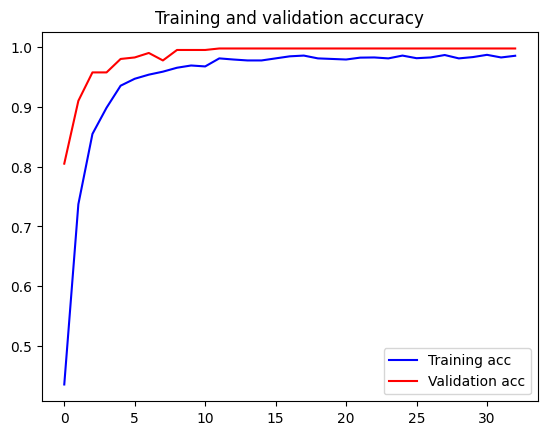

<Figure size 640x480 with 0 Axes>

In [17]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

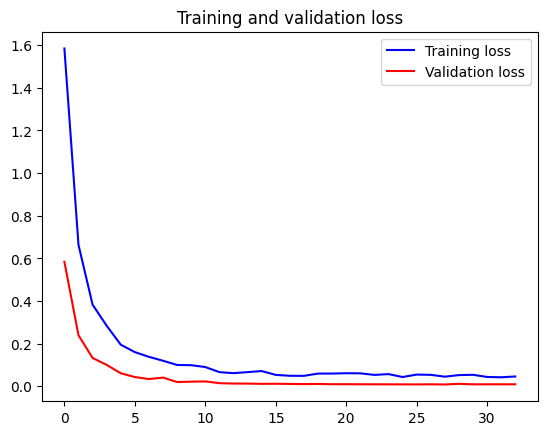

In [18]:
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [19]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

7/7 [==============================] - 1s 117ms/step - loss: 0.0185 - accuracy: 0.9925
Test Loss: 0.0185
Test Accuracy: 0.9925


7/7 [==============================] - 2s 131ms/step


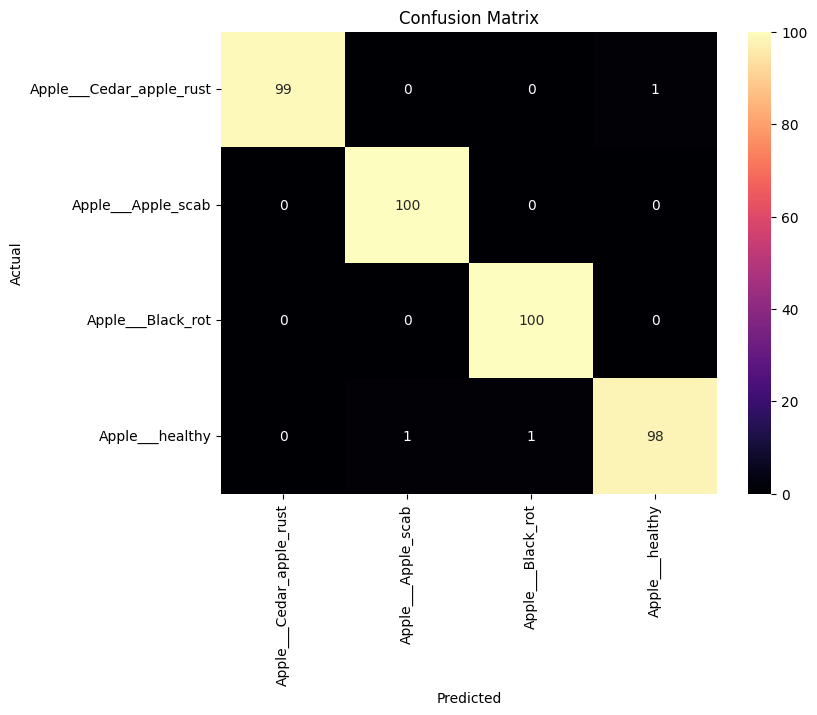

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming you have already trained and compiled your model
# train_ds is your training dataset

# Make predictions using the trained model
predictions = model.predict(test_generator)

# Convert predicted probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Get the actual labels from the dataset

# Calculate the confusion matrix
confusion_mtx = confusion_matrix(test_labels, predicted_labels)
classes = folders


import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have already trained and compiled your model
# train_ds is your training dataset
classes = folders
# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='magma',
            xticklabels=classes, yticklabels=classes)  # Replace 'classes' with your class labels
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



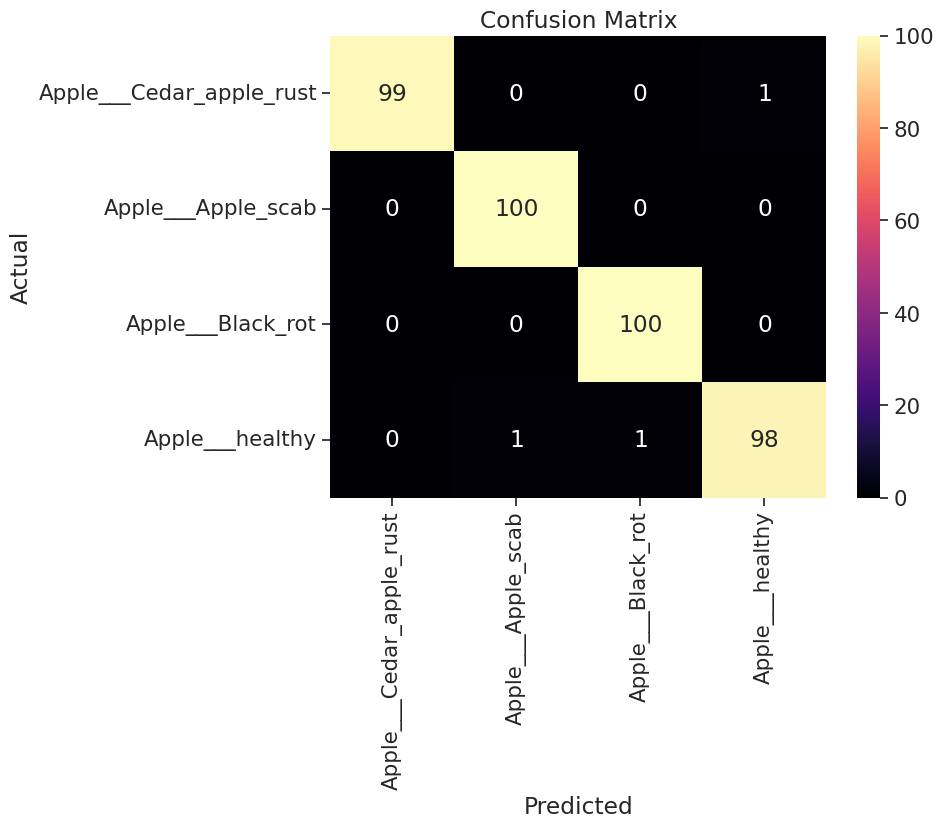

In [22]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have already trained and compiled your model
# train_ds is your training dataset
classes = folders
# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.4)  # Set the font scale
sns.set_style("ticks", {"font.family": "Times New Roman"})  # Set the font family to Times New Roman
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='magma',
            xticklabels=classes, yticklabels=classes)  # Replace 'classes' with your class labels
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [23]:
from sklearn.metrics import classification_report

# Assuming true_labels contains the ground truth labels and predicted_labels contains the predicted labels
report = classification_report(test_labels, predicted_labels)

print("Classification Report:")
print(report)


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       100
           1       0.99      1.00      1.00       100
           2       0.99      1.00      1.00       100
           3       0.99      0.98      0.98       100

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400



In [24]:
# prompt: python code for precision recall  and F1 score and plot it

from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate precision, recall, and F1 score
precision = precision_score(test_labels, predicted_labels, average='weighted')
recall = recall_score(test_labels, predicted_labels, average='weighted')
f1 = f1_score(test_labels, predicted_labels, average='weighted')

# Print the results
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)



Precision: 0.9925242524252426
Recall: 0.9925
F1 Score: 0.9924873121828045


In [30]:
from sklearn.metrics import roc_auc_score

# Calculate ROC-AUC score
roc_auc = roc_auc_score(test_labels, predictions, multi_class='ovr')

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.99995


7/7 [==============================] - 1s 140ms/step


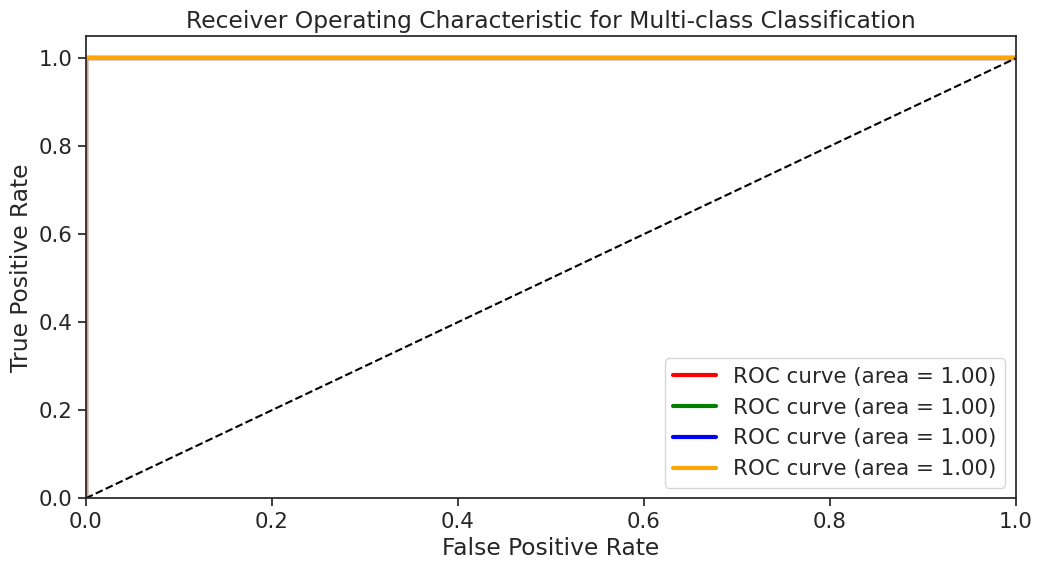

AUC scores:
Class 1: 1.0
Class 2: 1.0
Class 3: 1.0
Class 4: 1.0


In [32]:
# prompt: ROC Curve display for deep learning

# Get predicted probabilities for each class
predictions = model.predict(val_generator)

# Get the actual labels
test_labels = np.array(val_generator.labels)

# Binarize the test labels
test_labels_bin = keras.utils.to_categorical(test_labels)

# Calculate ROC curves and AUC for each class
fpr = {}
tpr = {}
auc_scores = {}

n_classes = 4  # Adjust this to your number of classes

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], predictions[:, i])
    auc_scores[i] = auc(fpr[i], tpr[i])

# Plot the ROC curves
plt.figure(figsize=(12, 6))


lw = 3
colors = ['red', 'green', 'blue', 'orange']  # Adjust colors for each class

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
             label='ROC curve (area = %0.2f)' % auc_scores[i])

plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Multi-class Classification')
plt.legend(loc="lower right")
plt.show()

# Print AUC scores
print('AUC scores:')
for i, score in auc_scores.items():
    print(f'Class {i+1}: {score}')